In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("synthetic_it_support_tickets.csv")

In [127]:
df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,customer_sentiment,csat_score,has_attachment,platform,region,days_take_to_resolve,month,year,day,hour
7423,TCKT_007424,2022-01-01 00:16:58,CUST_07612,enterprise,phone_transcript,mobile_app,how_to,low,resolved,gold,...,positive,0,0,ios,LATAM,0.791667,1,2022,Saturday,0
63267,TCKT_063268,2022-01-01 00:20:26,CUST_08390,enterprise,in_app,mobile_app,other,low,resolved,standard,...,negative,3,0,ios,APAC,0.625,1,2022,Saturday,0
89389,TCKT_089390,2022-01-01 00:31:35,CUST_08981,individual,email,api_integration,performance,high,in_progress,standard,...,very_negative,1,1,ios,MEA,<NA>,1,2022,Saturday,0
72649,TCKT_072650,2022-01-01 00:36:43,CUST_08982,individual,in_app,mobile_app,performance,medium,resolved,gold,...,negative,2,0,desktop_app,NaN,1.0,1,2022,Saturday,0
47616,TCKT_047617,2022-01-01 01:07:27,CUST_05368,individual,web_form,mobile_app,feature_request,high,closed_no_action,platinum,...,negative,3,0,api_client,EU,5.291667,1,2022,Saturday,1


In [4]:
df.shape

(100000, 20)

In [5]:
df.describe

<bound method NDFrame.describe of          ticket_id           created_at customer_id customer_segment  \
0      TCKT_000001  2024-01-31T05:14:27  CUST_00861       individual   
1      TCKT_000002  2024-10-20T06:15:49  CUST_00770       individual   
2      TCKT_000003  2024-06-18T21:35:54  CUST_02559   small_business   
3      TCKT_000004  2025-12-25T15:59:52  CUST_03557        education   
4      TCKT_000005  2023-08-27T16:08:33  CUST_09556       enterprise   
...            ...                  ...         ...              ...   
99995  TCKT_099996  2023-05-16T06:23:50  CUST_06828        education   
99996  TCKT_099997  2025-03-10T04:46:24  CUST_06621        education   
99997  TCKT_099998  2025-11-07T19:33:01  CUST_03719       non_profit   
99998  TCKT_099999  2022-06-20T22:29:10  CUST_02290   small_business   
99999  TCKT_100000  2022-02-27T14:33:20  CUST_06371        education   

                channel         product_area        issue_type priority  \
0                 email   

In [6]:
df = df.sort_values('created_at')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 7423 to 94026
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  object 
 1   created_at             100000 non-null  object 
 2   customer_id            100000 non-null  object 
 3   customer_segment       100000 non-null  object 
 4   channel                100000 non-null  object 
 5   product_area           100000 non-null  object 
 6   issue_type             100000 non-null  object 
 7   priority               100000 non-null  object 
 8   status                 100000 non-null  object 
 9   sla_plan               100000 non-null  object 
 10  initial_message        100000 non-null  object 
 11  agent_first_reply      100000 non-null  object 
 12  resolution_summary     60113 non-null   object 
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-null 

In [8]:
df['created_at']=pd.to_datetime(df['created_at'])

In [9]:
df['created_at'].info()

<class 'pandas.core.series.Series'>
Index: 100000 entries, 7423 to 94026
Series name: created_at
Non-Null Count   Dtype         
--------------   -----         
100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.5 MB


In [107]:
df['resolution_time_hours']=df['resolution_time_hours']

In [109]:
df['resolution_time_hours'].head(2)

7423     19
63267    15
Name: resolution_time_hours, dtype: Int64

In [110]:
df['days_take_to_resolve']=(df['resolution_time_hours']/24)

In [112]:
df['days_take_to_resolve'].head(2)

7423     0.791667
63267       0.625
Name: days_take_to_resolve, dtype: Float64

In [121]:
df[['resolution_time_hours','days_take_to_resolve']].round(2).head(2)

,resolution_time_hours,days_take_to_resolve
7423,19,0.79
63267,15,0.62


In [14]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
days_take_to_resolve     39887
dtype: int64

In [124]:
df['resolution_summary'].head(5)

7423     Provided step-by-step instructions and relevan...
63267    Provided general guidance and confirmed the is...
89389                                                  NaN
72649    Optimized queries and increased resource alloc...
47616    Ticket closed without further action after no ...
Name: resolution_summary, dtype: object

In [15]:
df[['resolution_summary', 'resolution_time_hours']].isnull().sum()

resolution_summary       39887
resolution_time_hours    39887
dtype: int64

In [128]:
# summary has null value and the reason is status is in progress
# and bcz the problem is not resolve till now resoltion_time_hour has null value
# and days_take_to_resolve has null values bcz it id create from resolution_time_hours 


# so the conclusion is we will not remove those null values

In [16]:
df[df['resolution_summary'].isnull() & 
   df['resolution_time_hours'].isnull()].shape

(39887, 21)

In [129]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['ticket_id'].duplicated().sum()


np.int64(0)

In [19]:
df.dtypes

ticket_id                        object
created_at               datetime64[ns]
customer_id                      object
customer_segment                 object
channel                          object
product_area                     object
issue_type                       object
priority                         object
status                           object
sla_plan                         object
initial_message                  object
agent_first_reply                object
resolution_summary               object
resolution_time_hours             Int64
reopened                          int64
customer_sentiment               object
csat_score                        int64
has_attachment                    int64
platform                         object
region                           object
days_take_to_resolve              Int64
dtype: object

In [132]:
print("priority unique value:",df['priority'].unique())
print("status unique value:",df['status'].unique())
print("sla_plan unique value:",df['sla_plan'].unique())
print("issue_type unique value:",df['issue_type'].unique())
print("channel unique value:",df['channel'].unique())

priority unique value: ['low' 'high' 'medium' 'urgent']
status unique value: ['resolved' 'in_progress' 'closed_no_action' 'open' 'on_hold']
sla_plan unique value: ['gold' 'standard' 'platinum']
issue_type unique value: ['how_to' 'other' 'performance' 'feature_request' 'security_concern'
 'account_access' 'billing_problem' 'bug']
channel unique value: ['phone_transcript' 'in_app' 'email' 'web_form' 'chat']


In [134]:
print("resolution summary unique value:", df['resolution_summary'].nunique())

resolution summary unique value: 9


In [21]:
print("resolution summary unique value", df['resolution_summary'].unique())

resolution summary unique value ['Provided step-by-step instructions and relevant documentation.'
 'Provided general guidance and confirmed the issue was resolved.' nan
 'Optimized queries and increased resource allocation.'
 'Ticket closed without further action after no response from the customer.'
 'Captured the request and added it to the product backlog.'
 'Investigated logs, mitigated the issue, and updated security settings.'
 'Adjusted the invoice and issued a refund where applicable.'
 'Patched the bug and deployed a fix to production.'
 'Reset account credentials and confirmed successful login.']


In [22]:
df['priority'].value_counts()

priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64

In [23]:
df['status'].value_counts()

status
resolved            50131
in_progress         19783
on_hold             10165
closed_no_action     9982
open                 9939
Name: count, dtype: int64

In [24]:
df['sla_plan'].value_counts()

sla_plan
standard    60066
gold        29875
platinum    10059
Name: count, dtype: int64

In [25]:
df['issue_type'].value_counts()

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

In [26]:

df['channel'].value_counts()

channel
phone_transcript    20133
email               20088
in_app              19982
web_form            19965
chat                19832
Name: count, dtype: int64

In [27]:
high_inprogress= df[(df['status']=="in_progress") &( df['priority']=="high")]

In [136]:
high_inprogress.shape

(3982, 21)

In [153]:
high_inprogress.head(2)

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region,days_take_to_resolve
89389,TCKT_089390,2022-01-01 00:31:35,CUST_08981,individual,email,api_integration,performance,high,in_progress,standard,...,We understand performance issues can be frustr...,NaN,<NA>,0,very_negative,1,1,ios,MEA,<NA>
9031,TCKT_009032,2022-01-01 21:38:25,CUST_08202,non_profit,email,api_integration,security_concern,high,in_progress,standard,...,We take security very seriously. We are priori...,NaN,<NA>,0,neutral,4,1,android,APAC,<NA>


In [139]:
high_resolved = df[(df['priority']=="high")&(df['status']=="resolved")]

In [140]:
high_resolved.shape

(9945, 25)

In [154]:
## urgent inprogress

In [29]:
urgent_inprogress= df[(df['status']=="in_progress") &( df['priority']=="urgent")]

In [148]:
urgent_inprogress.shape[0]

987

In [149]:
urgent_inprogress.head(2)

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region,days_take_to_resolve
24179,TCKT_024180,2022-01-03 09:40:27,CUST_06907,small_business,email,data_export,how_to,urgent,in_progress,standard,...,Happy to help with your question. This has bee...,NaN,<NA>,0,neutral,4,1,desktop_app,APAC,<NA>
29636,TCKT_029637,2022-01-04 00:42:45,CUST_05281,education,phone_transcript,data_export,performance,urgent,in_progress,gold,...,We understand performance issues can be frustr...,NaN,<NA>,0,very_positive,0,0,ios,APAC,<NA>


In [150]:
df[df['status']=="closed_no_action"].shape[0]

9982

In [32]:
# how many tickets are close bcz od no response from the user

closed_no_response= df[( df['status']=="closed_no_action")& (df['resolution_summary'].str.contains("no response", case=False,na=False))]

In [152]:
closed_no_response.shape[0]

9982

In [34]:
df['customer_id'].duplicated().sum()

np.int64(90001)

In [35]:
df['customer_id'].value_counts().head(20)

customer_id
CUST_07153    26
CUST_08898    23
CUST_05691    23
CUST_06035    22
CUST_05381    22
CUST_06800    22
CUST_04334    22
CUST_05674    21
CUST_07857    21
CUST_03123    21
CUST_04731    21
CUST_08609    21
CUST_02174    21
CUST_00115    21
CUST_06156    21
CUST_07046    21
CUST_01986    21
CUST_05907    21
CUST_04598    20
CUST_02662    20
Name: count, dtype: int64

In [36]:
df[(df['customer_id'] == 'CUST_07153')].head(20)

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region,days_take_to_resolve
58576,TCKT_058577,2022-01-06 05:03:04,CUST_07153,education,email,data_export,account_access,low,resolved,gold,...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,58,0,very_negative,1,0,api_client,MEA,5
82633,TCKT_082634,2022-01-21 05:17:33,CUST_07153,education,phone_transcript,mobile_app,feature_request,high,resolved,platinum,...,Thanks for your feature suggestion. We are pri...,Captured the request and added it to the produ...,4,0,positive,0,0,ios,LATAM,0
58875,TCKT_058876,2022-01-30 09:19:24,CUST_07153,enterprise,in_app,mobile_app,how_to,medium,resolved,standard,...,Happy to help with your question. Our team is ...,Provided step-by-step instructions and relevan...,24,0,very_positive,5,1,ios,MEA,2
63869,TCKT_063870,2022-10-13 22:34:09,CUST_07153,non_profit,web_form,api_integration,security_concern,low,resolved,platinum,...,We take security very seriously. We will look ...,"Investigated logs, mitigated the issue, and up...",25,0,negative,2,1,web,LATAM,2
45042,TCKT_045043,2022-10-28 21:44:40,CUST_07153,individual,phone_transcript,billing,other,low,open,standard,...,Thanks for contacting support. We will look in...,NaN,<NA>,0,neutral,0,0,ios,LATAM,<NA>
86795,TCKT_086796,2023-01-04 20:13:31,CUST_07153,education,in_app,analytics_dashboard,other,medium,on_hold,standard,...,Thanks for contacting support. Our team is rev...,NaN,<NA>,0,neutral,0,0,web,EU,<NA>
76258,TCKT_076259,2023-02-06 18:49:16,CUST_07153,small_business,in_app,billing,security_concern,low,open,gold,...,We take security very seriously. We will look ...,NaN,<NA>,0,positive,5,1,desktop_app,NaN,<NA>
92342,TCKT_092343,2023-07-18 00:52:50,CUST_07153,enterprise,in_app,login_auth,performance,low,resolved,gold,...,We understand performance issues can be frustr...,Optimized queries and increased resource alloc...,36,0,neutral,3,0,web,LATAM,3
11076,TCKT_011077,2023-09-19 06:48:05,CUST_07153,individual,chat,billing,performance,low,resolved,standard,...,We understand performance issues can be frustr...,Optimized queries and increased resource alloc...,10,0,very_negative,2,0,ios,MEA,1
63766,TCKT_063767,2023-11-04 07:40:24,CUST_07153,small_business,chat,notifications,performance,medium,closed_no_action,standard,...,We understand performance issues can be frustr...,Ticket closed without further action after no ...,66,0,negative,2,0,desktop_app,EU,6


In [156]:
security_concern =df[(df['customer_id'] == 'CUST_07153') &(df['product_area']=="api_integration") & (df['issue_type']=="security_concern") ]

In [157]:
security_concern

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,customer_sentiment,csat_score,has_attachment,platform,region,days_take_to_resolve,month,year,day,hour
63869,TCKT_063870,2022-10-13 22:34:09,CUST_07153,non_profit,web_form,api_integration,security_concern,low,resolved,platinum,...,negative,2,1,web,LATAM,1.041667,10,2022,Thursday,22
1934,TCKT_001935,2025-12-23 00:46:37,CUST_07153,non_profit,email,api_integration,security_concern,high,closed_no_action,standard,...,neutral,4,0,web,EU,9.666667,12,2025,Tuesday,0


In [38]:
customer_tickets = df[
    df['customer_id'].duplicated(keep=False)
].sort_values('customer_id')

customer_tickets[
    ['customer_id', 'ticket_id', 'created_at',
     'issue_type', 'initial_message']
].head(50)

,customer_id,ticket_id,created_at,issue_type,initial_message
80790,CUST_00001,TCKT_080791,2023-09-16 15:22:06,billing_problem,I was charged twice for my subscription this m...
32124,CUST_00001,TCKT_032125,2022-07-04 06:43:30,bug,The page keeps crashing whenever I try to open...
46992,CUST_00001,TCKT_046993,2025-03-02 10:13:16,other,I need help but I'm not sure which category th...
86020,CUST_00001,TCKT_086021,2025-02-18 09:47:57,account_access,My account was locked after multiple failed lo...
3544,CUST_00001,TCKT_003545,2023-06-05 06:13:59,account_access,My 2FA code is not working when I try to sign in.
82074,CUST_00001,TCKT_082075,2025-09-03 18:31:33,how_to,Can you explain how to configure api integrati...
42111,CUST_00001,TCKT_042112,2023-10-07 22:23:37,security_concern,I noticed a suspicious login on my account.
67026,CUST_00001,TCKT_067027,2022-11-16 10:11:17,how_to,Can you explain how to configure notifications...
97281,CUST_00002,TCKT_097282,2024-01-19 20:45:17,account_access,I cannot log in; the system says my password i...
94867,CUST_00002,TCKT_094868,2023-05-30 04:47:43,security_concern,There seems to be a vulnerability in the data ...


In [39]:
# How many tickets are there for each priority?

df['ticket_id'].groupby(df['priority']).count()

priority
high      19865
low       39735
medium    35313
urgent     5087
Name: ticket_id, dtype: int64

In [159]:
# df.groupby('priority').size()

In [41]:
# How many tickets are there for each status?
df['ticket_id'].groupby(df['status']).count()

status
closed_no_action     9982
in_progress         19783
on_hold             10165
open                 9939
resolved            50131
Name: ticket_id, dtype: int64

In [160]:
# How many tickets are there for each issue type?
df['ticket_id'].groupby(df['issue_type']).count()

issue_type
account_access      12609
billing_problem     12382
bug                 12349
feature_request     12487
how_to              12739
other               12463
performance         12513
security_concern    12458
Name: ticket_id, dtype: int64

In [164]:
# What is the average resolution_time_hours for each priority?
round(df['resolution_time_hours'].groupby(df['priority']).mean(),0).astype(str)+" hours"

priority
high      32.0 hours
low       56.0 hours
medium    43.0 hours
urgent    27.0 hours
Name: resolution_time_hours, dtype: object

In [165]:
# What is the average days_take_to_resolve for each priority?
round(df['days_take_to_resolve'].groupby(df['priority']).mean(),2).astype(str)+" days"

priority
high      1.31 days
low       2.32 days
medium     1.8 days
urgent    1.11 days
Name: days_take_to_resolve, dtype: object

In [168]:
# What is the average CSAT score for each issue_type?
round(df['csat_score'].groupby(df['issue_type']).mean(),2).astype(str)+" rating"

issue_type
account_access      1.97 rating
billing_problem     1.98 rating
bug                 2.41 rating
feature_request      2.6 rating
how_to              2.61 rating
other               2.42 rating
performance         1.97 rating
security_concern    1.97 rating
Name: csat_score, dtype: object

In [45]:
# What is the average CSAT score for each priority?
round(df['csat_score'].groupby(df['priority']).mean(),2)

priority
high      2.25
low       2.24
medium    2.24
urgent    2.24
Name: csat_score, dtype: float64

In [46]:
# What is the overall average customer satisfaction score?
print("avg customer satisfaction score:",df['csat_score'].mean())

avg customer satisfaction score: 2.24195


In [47]:
# For each priority, what is the average resolution_time_hours AND average csat_score?
round(df[['resolution_time_hours','csat_score']].groupby(df['priority']).mean(),2)

,resolution_time_hours,csat_score
priority,,
high,31.56,2.25
low,55.61,2.24
medium,43.28,2.24
urgent,26.7,2.24


In [172]:
# What is the average resolution_time_hours  and days for each issue_type?
round(df[['resolution_time_hours','days_take_to_resolve']].groupby(df['issue_type']).mean(),2)

,resolution_time_hours,days_take_to_resolve
issue_type,,
account_access,44.98,1.87
billing_problem,45.13,1.88
bug,44.3,1.85
feature_request,45.71,1.9
how_to,45.42,1.89
other,44.56,1.86
performance,44.71,1.86
security_concern,45.26,1.89


In [173]:
# What is the average resolution time and days for each channel?
df[['resolution_time_hours','days_take_to_resolve']].groupby(df['channel']).mean()

,resolution_time_hours,days_take_to_resolve
channel,,
chat,45.394932,1.891456
email,45.160825,1.881701
in_app,44.953113,1.873046
phone_transcript,45.119755,1.87999
web_form,44.430794,1.851283


In [50]:
# What is the average CSAT score for each channel?

In [51]:
df['csat_score'].groupby(df['channel']).mean()

channel
chat                2.250000
email               2.233423
in_app              2.255680
phone_transcript    2.224557
web_form            2.246331
Name: csat_score, dtype: float64

In [174]:
# For each priority, find:

# Number of tickets
# Average resolution time
# Average CSAT score

df.groupby('priority').agg(
    ticket_count = ("ticket_id","count"),
    avg_resolution_time= ("resolution_time_hours","mean"),
    avg_csat_score = ("csat_score","mean")
)

,ticket_count,avg_resolution_time,avg_csat_score
priority,,,
high,19865,31.559249,2.249081
low,39735,55.606504,2.237750
medium,35313,43.283079,2.243055
urgent,5087,26.703911,2.239237


DATA ANALYSIS

In [211]:
# For each year, which month had the highest number of tickets?
df['month']=df['created_at'].dt.month
df['year'] =df['created_at'].dt.year
monthly_tickets=df.groupby(['year','month'])['ticket_id'].count().reset_index(name="ticket_count")
# monthly_tickets

In [200]:
monthly_tickets.loc[monthly_tickets.groupby('year')['ticket_count'].idxmax()] 


,year,month,ticket_count
2,2022,3,2139
18,2023,7,2263
31,2024,8,2211
36,2025,1,2158


In [201]:
# Which year had the highest number of support tickets?
df['ticket_id'].groupby(df['year']).count().sort_values(ascending= False)

year
2023    25165
2025    25162
2024    25070
2022    24603
Name: ticket_id, dtype: int64

In [202]:
# Which day of the week receives the highest number of support tickets?
df['day']=df['created_at'].dt.day_name()

In [63]:
df['day'].head()

7423     Saturday
63267    Saturday
89389    Saturday
72649    Saturday
47616    Saturday
Name: day, dtype: object

In [203]:
df.groupby(['year','month','day'])['ticket_id'].count().head(20)

year  month  day      
2022  1      Friday       254
             Monday       320
             Saturday     360
             Sunday       357
             Thursday     305
             Tuesday      273
             Wednesday    240
      2      Friday       264
             Monday       280
             Saturday     259
             Sunday       247
             Thursday     279
             Tuesday      259
             Wednesday    247
      3      Friday       255
             Monday       269
             Saturday     297
             Sunday       287
             Thursday     337
             Tuesday      342
Name: ticket_id, dtype: int64

In [65]:
df['ticket_id'].groupby(df['day']).count().sort_values(ascending=False)

day
Monday       14389
Saturday     14367
Wednesday    14324
Tuesday      14309
Thursday     14302
Sunday       14237
Friday       14072
Name: ticket_id, dtype: int64

In [204]:
df.columns

Index(['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel',
       'product_area', 'issue_type', 'priority', 'status', 'sla_plan',
       'initial_message', 'agent_first_reply', 'resolution_summary',
       'resolution_time_hours', 'reopened', 'customer_sentiment', 'csat_score',
       'has_attachment', 'platform', 'region', 'days_take_to_resolve', 'month',
       'year', 'day', 'hour'],
      dtype='object')

In [246]:
# Which hour of the day receives the highest number of tickets?
df['time']= df['created_at'].dt.hour
df.groupby(['day', 'time'])['ticket_id'].count().head(20)

day     time
Friday  0       598
        1       588
        2       583
        3       595
        4       602
        5       576
        6       577
        7       592
        8       565
        9       607
        10      577
        11      567
        12      590
        13      603
        14      570
        15      601
        16      600
        17      600
        18      630
        19      571
Name: ticket_id, dtype: int64

In [247]:
df.groupby('time')['ticket_id'].count().sort_values(ascending=False)

time
15    4314
4     4254
7     4249
2     4227
0     4223
19    4205
17    4201
5     4196
16    4192
12    4189
18    4182
14    4162
20    4161
1     4160
10    4153
9     4152
13    4139
6     4135
11    4133
3     4124
21    4116
22    4096
8     4039
23    3998
Name: ticket_id, dtype: int64

In [212]:
# For each year, which month had the highest number of tickets?
df.groupby(['year','month'])['ticket_id'].count().head(20)

year  month
2022  1        2109
      2        1835
      3        2139
      4        2044
      5        2044
      6        2092
      7        2070
      8        2091
      9        2006
      10       2094
      11       2056
      12       2023
2023  1        2068
      2        1978
      3        2148
      4        2039
      5        2066
      6        2038
      7        2263
      8        2098
Name: ticket_id, dtype: int64

In [70]:
# Which priority has the highest average resolution time?
avg_res_time = round(df['resolution_time_hours'].groupby(df['priority']).mean(),0).sort_values(ascending=False)
print(avg_res_time)

priority
low       56.0
medium    43.0
high      32.0
urgent    27.0
Name: resolution_time_hours, dtype: Float64


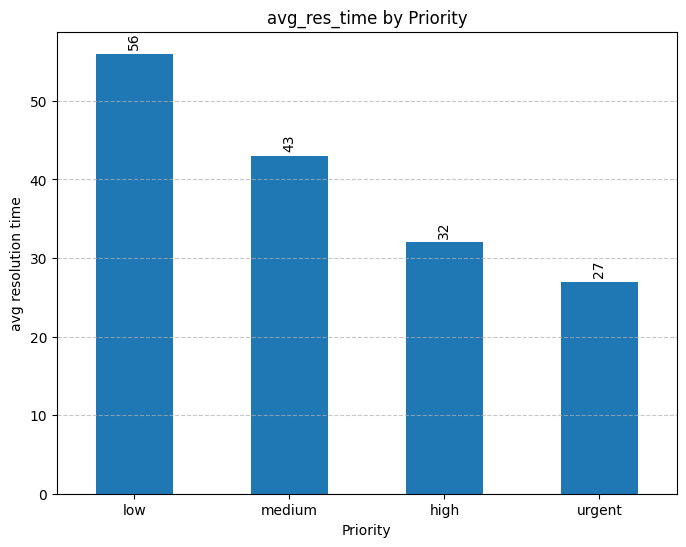

In [71]:
ax = avg_res_time.plot(kind='bar',figsize=(8,6))
plt.title('avg_res_time by Priority')
plt.xlabel('Priority')
plt.ylabel('avg resolution time')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        rotation=90
    )
plt.show()

In [213]:
# For each priority, how many tickets are in each status?
df.groupby(['priority', 'status'])['ticket_id'].count()

priority  status          
high      closed_no_action     1937
          in_progress          3982
          on_hold              2056
          open                 1945
          resolved             9945
low       closed_no_action     4014
          in_progress          7877
          on_hold              4003
          open                 4025
          resolved            19816
medium    closed_no_action     3495
          in_progress          6937
          on_hold              3573
          open                 3445
          resolved            17863
urgent    closed_no_action      536
          in_progress           987
          on_hold               533
          open                  524
          resolved             2507
Name: ticket_id, dtype: int64

In [214]:
priority_status= df.groupby(['priority', 'status'])['ticket_id'].count().unstack()

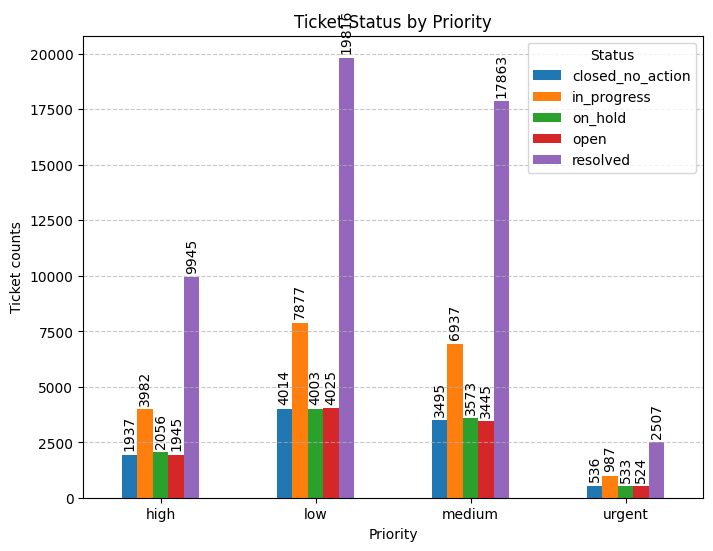

In [216]:
ax = priority_status.plot(kind='bar',figsize=(8,6))
plt.title('Ticket Status by Priority')
plt.xlabel('Priority')
plt.ylabel('Ticket counts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Status')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        rotation=90
    )

plt.show()

In [217]:
# Which issue type has the highest number of reopened tickets?
tot_reopen_by_issue_typ = df[df['reopened']==1].groupby(df['issue_type'])['reopened'].count()
print(tot_reopen_by_issue_typ)


issue_type
account_access      659
billing_problem     609
bug                 622
feature_request     623
how_to              613
other               633
performance         658
security_concern    628
Name: reopened, dtype: int64


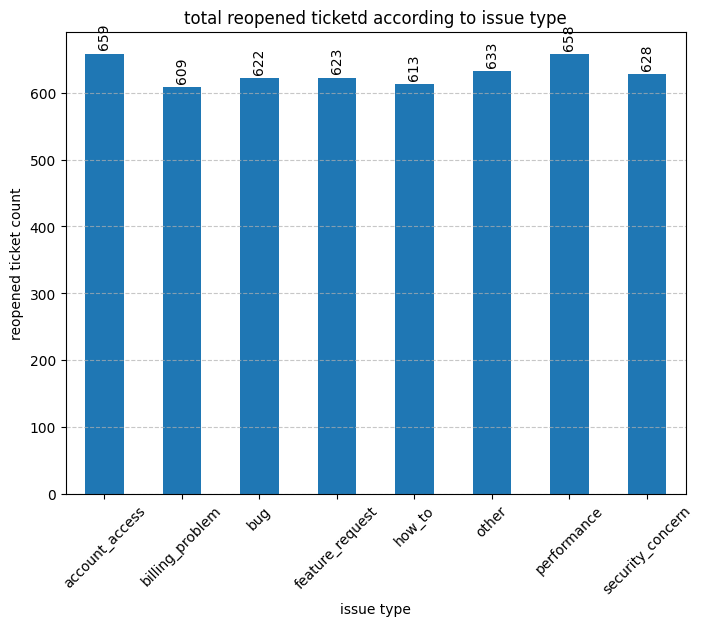

In [218]:
ax=tot_reopen_by_issue_typ.plot(kind='bar', figsize=(8,6))
plt.title("total reopened ticketd according to issue type")
plt.xlabel("issue type")
plt.ylabel("reopened ticket count")
plt.grid(axis='y', linestyle='--', alpha= 0.7)
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        rotation=90
    )
plt.show()

In [219]:
# How many tickets were reopened for each priority?
tot_reopen_by_priority = df[df['reopened']==1].groupby(df['priority'])['reopened'].count()
print(tot_reopen_by_priority )

priority
high      1012
low       1985
medium    1770
urgent     278
Name: reopened, dtype: int64


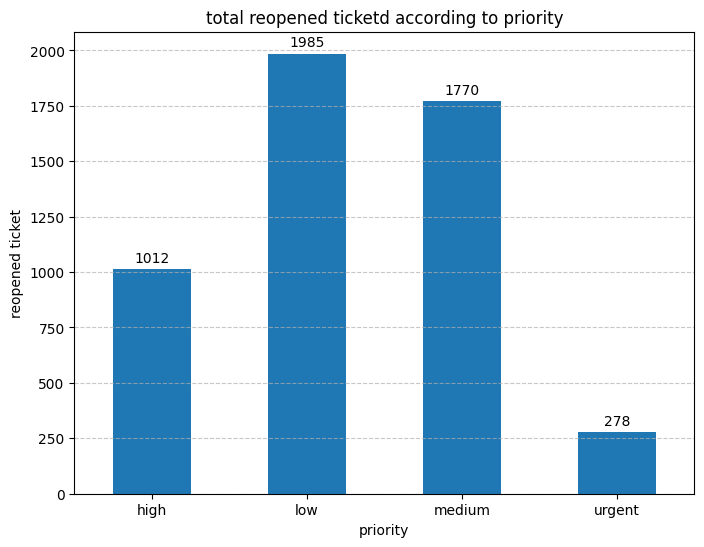

In [220]:
ax=tot_reopen_by_priority.plot(kind='bar', figsize=(8,6))
plt.title("total reopened ticketd according to priority")
plt.xlabel("priority")
plt.ylabel("reopened ticket")
plt.grid(axis='y', linestyle='--', alpha= 0.7)
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        rotation=0
    )
plt.show()

In [221]:
# how many types of sla plan exist and how many tickets are raised in each sla plan 
sla_counts=df['sla_plan'].value_counts()
print(sla_counts)

sla_plan
standard    60066
gold        29875
platinum    10059
Name: count, dtype: int64


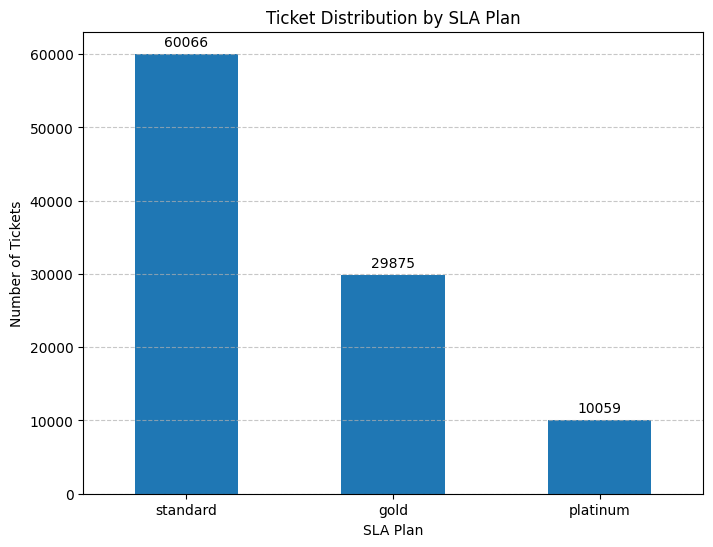

In [222]:
ax = sla_counts.plot(
    kind='bar',
    figsize=(8, 6)
)

plt.title('Ticket Distribution by SLA Plan')
plt.xlabel('SLA Plan')
plt.ylabel('Number of Tickets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        rotation=0
    )

plt.show()

In [223]:
# Average Resolution Time by SLA Plan
avg_res_time_by_sla = df['resolution_time_hours'].groupby(df['sla_plan']).mean()
print(avg_res_time_by_sla)

sla_plan
gold        45.134961
platinum    44.245709
standard    45.076208
Name: resolution_time_hours, dtype: Float64


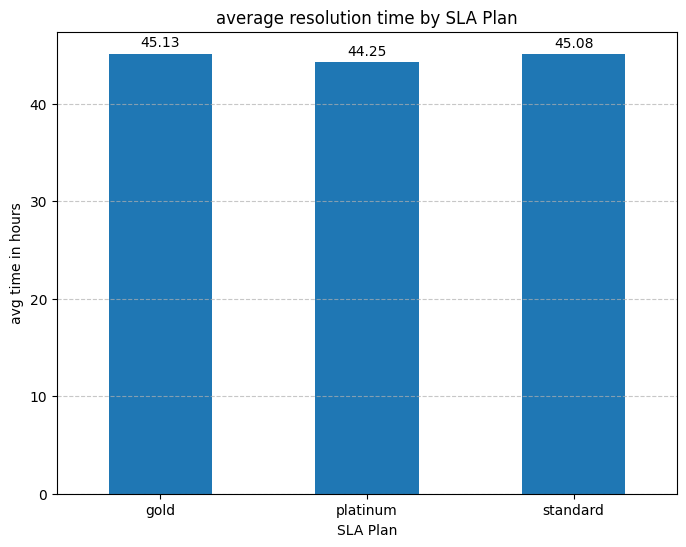

In [224]:
ax = avg_res_time_by_sla.plot(
    kind='bar',
    figsize=(8, 6)
)

plt.title('average resolution time by SLA Plan')
plt.xlabel('SLA Plan')
plt.ylabel('avg time in hours')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3,
        rotation=0
    )

plt.show()

In [225]:
# Count each CSAT score
csat_rating_count = df['csat_score'].value_counts().sort_index()
print(csat_rating_count)

csat_score
0    29941
1     5815
2    14871
3    20453
4    17321
5    11599
Name: count, dtype: int64


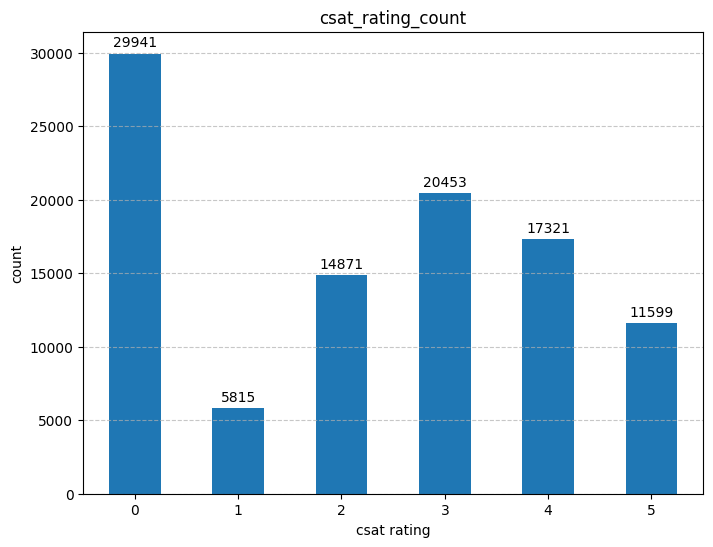

In [226]:
ax = csat_rating_count.plot(
    kind='bar',
    figsize=(8, 6)
)

plt.title('csat_rating_count')
plt.xlabel('csat rating')
plt.ylabel('count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        rotation=0
    )

plt.show()

In [227]:
# How are customers feeling about their support experience?

cus_sentiment = df['customer_sentiment'].value_counts()
print(cus_sentiment)

customer_sentiment
neutral          32634
negative         26015
very_negative    16437
positive         16242
very_positive     8672
Name: count, dtype: int64


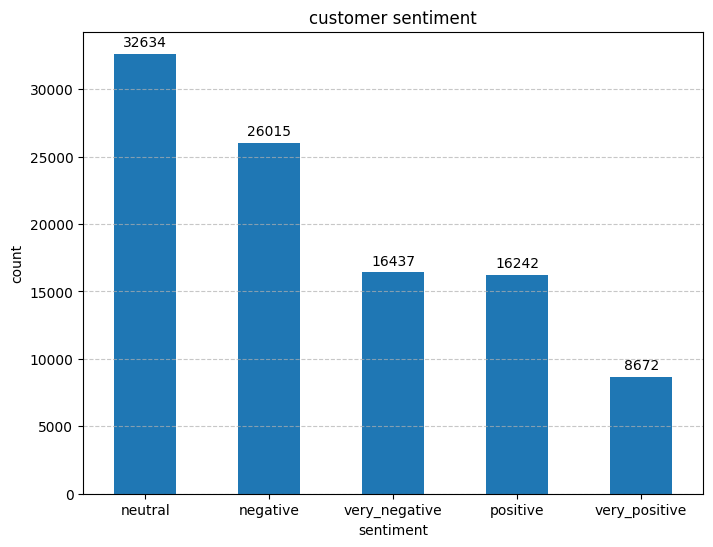

In [228]:
ax = cus_sentiment.plot(
    kind='bar',
    figsize=(8, 6)
)

plt.title('customer sentiment')
plt.xlabel('sentiment')
plt.ylabel('count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        rotation=0
    )

plt.show()

In [231]:
# Calculate average CSAT by sentiment
csat_by_sentiment = (
    df.groupby('customer_sentiment')['csat_score']
      .mean()
      .round(2)
      
)

csat_by_sentiment

customer_sentiment
negative         1.75
neutral          2.46
positive         3.14
very_negative    1.05
very_positive    3.51
Name: csat_score, dtype: float64

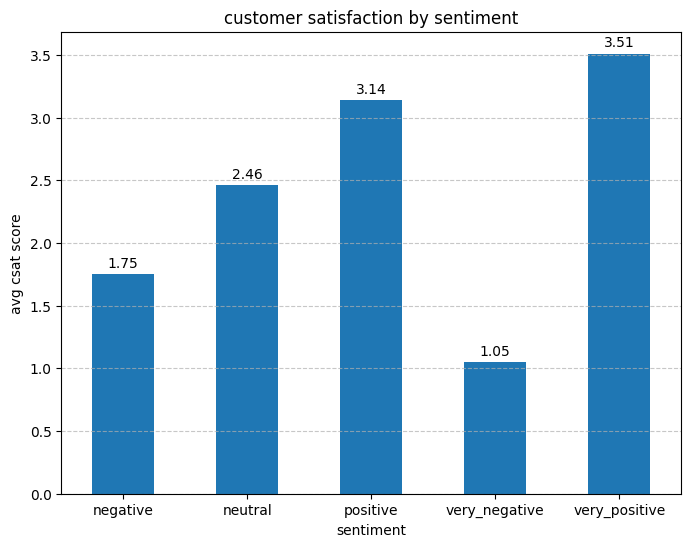

In [232]:
ax = csat_by_sentiment.plot(
    kind='bar',
    figsize=(8, 6)
)

plt.title('customer satisfaction by sentiment')
plt.xlabel('sentiment')
plt.ylabel('avg csat score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3,
        rotation=0
    )

plt.show()

In [244]:
# saving file
df.to_excel('synthetic_it_support_tickets.xlsx',index=False)

In [245]:
import os
os.getcwd()

'C:\\Users\\Asus\\Service_desk_ticket_analysis'